In [10]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [11]:
# 1. Load data
df = pd.read_csv("/content/diabetic_data.csv")

# 2. Automatically grab all numeric columns, dropping only raw ID numbers
X = df.select_dtypes("number").drop(columns=["encounter_id", "patient_nbr"])
y = (df["readmitted"] == "<30").astype(int)

# 3. Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
# 4. Scale features & train Logistic Regression with L2 Regularization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(penalty="l2", max_iter=500)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=500)

In [13]:
# 5. Evaluate with ROC-AUC
y_probs = model.predict_proba(X_test_scaled)[:, 1]
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_probs):.4f}")

ROC-AUC Score: 0.6408


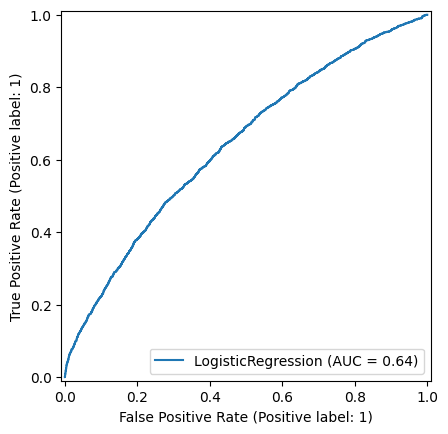

In [14]:
# 6. Plot ROC Curve
RocCurveDisplay.from_estimator(model, X_test_scaled, y_test)
plt.show()

In [15]:
# 7. Clinical Cost Comparison
for threshold in [0.50, 0.15]:
    preds = (y_probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    cost = (fn * 10000) + (fp * 500)
    print(
        f"Threshold {threshold:.2f} -> Missed (FN): {fn} | Extra Calls (FP): {fp} | Cost: ${cost:,}"
    )

Threshold 0.50 -> Missed (FN): 2242 | Extra Calls (FP): 34 | Cost: $22,437,000
Threshold 0.15 -> Missed (FN): 1718 | Extra Calls (FP): 1989 | Cost: $18,174,500
